# MScFE 620 — Derivative Pricing — Group Work Project 1
### Team Member B contributions + Group sections (Step 1 theory, Step 3)

**Step 1 / Step 2 parameters:** $S_0=100$, $r=5\%$, $\sigma=20\%$, $T=3$ months $=0.25$ yr.

This notebook prices vanilla options with **binomial (CRR)** and **trinomial (Boyle)** trees,
computes the Greeks **Delta** and **Vega**, verifies **put-call parity**, and runs the
**dynamic delta-hedging** simulation of Step 3. All prices are rounded to the nearest cent
and presented in tables.

## Step 1 — Put-Call Parity

**Q1. Does put-call parity hold for European options? Why?**
Yes. For non-dividend-paying European options it holds exactly:
$$C - P = S_0 - K e^{-rT}.$$
The reason is **no-arbitrage replication**. A portfolio long one call and short one put pays
$(S_T-K)^+ - (K-S_T)^+ = S_T - K$ at expiry in every state. A portfolio long one share and short
$K e^{-rT}$ in cash also delivers $S_T - K$. Two portfolios with identical payoffs in **every**
state must cost the same today, else a riskless arbitrage exists. Hence $C-P = S_0 - Ke^{-rT}$.

**Q2. Call in terms of everything else:** $\;C = P + S_0 - K e^{-rT}.$

**Q3. Put in terms of everything else:** $\;P = C - S_0 + K e^{-rT}.$

**Q4. Does put-call parity hold for American options? Why/why not?**
No — only an inequality band holds. Early exercise of the American put adds an *early-exercise
premium* that breaks the equality. For non-dividend stock,
$$S_0 - K \le C - P \le S_0 - K e^{-rT}.$$
(The American call on non-dividend stock is never exercised early, so $C_{Am}=C_{Eu}$, but
$P_{Am}\ge P_{Eu}$, widening the equality into a band.)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
pd.set_option("display.float_format", lambda x: f"{x:0.2f}")

# ---- Step 1 / Step 2 base parameters ----
S0, r, sigma, T = 100.0, 0.05, 0.20, 0.25

## Pricing engines

Two recombining lattices, each able to price European or American calls and puts by backward
induction. American style applies the early-exercise test
$V=\max(\text{continuation},\ \text{intrinsic})$ at every node.

In [2]:
def crr_tree(S, K, r, sigma, T, N, kind="call", american=False):
    """Cox-Ross-Rubinstein binomial tree. Returns option price at t=0."""
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt)); d = 1 / u
    p = (np.exp(r * dt) - d) / (u - d); disc = np.exp(-r * dt)
    j = np.arange(N + 1); ST = S * u**j * d**(N - j)
    V = np.maximum(ST - K, 0) if kind == "call" else np.maximum(K - ST, 0)
    for i in range(N - 1, -1, -1):
        j = np.arange(i + 1); Si = S * u**j * d**(i - j)
        V = disc * (p * V[1:i + 2] + (1 - p) * V[0:i + 1])
        if american:
            ex = np.maximum(Si - K, 0) if kind == "call" else np.maximum(K - Si, 0)
            V = np.maximum(V, ex)
    return float(V[0])

def crr_delta(S, K, r, sigma, T, N, kind="call", american=False):
    """Delta from the first time-step of the CRR tree: (Vu - Vd)/(Su - Sd)."""
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt)); d = 1 / u
    p = (np.exp(r * dt) - d) / (u - d); disc = np.exp(-r * dt)
    j = np.arange(N + 1); ST = S * u**j * d**(N - j)
    V = np.maximum(ST - K, 0) if kind == "call" else np.maximum(K - ST, 0)
    Vu = Vd = None
    for i in range(N - 1, -1, -1):
        j = np.arange(i + 1); Si = S * u**j * d**(i - j)
        V = disc * (p * V[1:i + 2] + (1 - p) * V[0:i + 1])
        if american:
            ex = np.maximum(Si - K, 0) if kind == "call" else np.maximum(K - Si, 0)
            V = np.maximum(V, ex)
        if i == 1: Vu, Vd = V[1], V[0]
    return float((Vu - Vd) / (S * u - S * d))

def trinomial_tree(S, K, r, sigma, T, N, kind="call", american=False):
    """Boyle trinomial tree. Returns option price at t=0."""
    dt = T / N
    u = np.exp(sigma * np.sqrt(2 * dt)); d = 1 / u
    a = np.exp(r*dt/2); b1 = np.exp(sigma*np.sqrt(dt/2)); b2 = np.exp(-sigma*np.sqrt(dt/2))
    pu = ((a-b2)/(b1-b2))**2; pd = ((b1-a)/(b1-b2))**2; pm = 1-pu-pd; disc = np.exp(-r*dt)
    j = np.arange(2*N+1); ST = S * u**(N-j)
    V = np.maximum(ST-K,0) if kind=="call" else np.maximum(K-ST,0)
    for i in range(N-1,-1,-1):
        j = np.arange(2*i+1); Si = S*u**(i-j)
        V = disc*(pu*V[0:2*i+1] + pm*V[1:2*i+2] + pd*V[2:2*i+3])
        if american:
            ex = np.maximum(Si-K,0) if kind=="call" else np.maximum(K-Si,0)
            V = np.maximum(V, ex)
    return float(V[0])

### Step-count justification

Binomial prices oscillate around the true value and converge as $N$ grows. The table shows the ATM
European call converging to Black-Scholes; by $N\approx250$–$500$ it is stable to the cent, so we
use **$N=500$** for binomial pricing.

In [3]:
def bs(S, K, r, sigma, T, kind):
    d1 = (np.log(S/K)+(r+sigma**2/2)*T)/(sigma*np.sqrt(T)); d2 = d1-sigma*np.sqrt(T)
    if kind=="call": return S*norm.cdf(d1)-K*np.exp(-r*T)*norm.cdf(d2)
    return K*np.exp(-r*T)*norm.cdf(-d2)-S*norm.cdf(-d1)

rows = [{"N steps": N, "Binomial call": round(crr_tree(S0,100,r,sigma,T,N,"call",False),4)}
        for N in [10,25,50,100,250,500,1000]]
conv = pd.DataFrame(rows)
conv["Black-Scholes"] = round(bs(S0,100,r,sigma,T,"call"),4)
conv["abs error"] = (conv["Binomial call"]-conv["Black-Scholes"]).abs().round(4)
N_BIN = 500
conv

,N steps,Binomial call,Black-Scholes,abs error
0,10,4.52,4.62,0.10
1,25,4.65,4.62,0.04
2,50,4.60,4.62,0.02
3,100,4.61,4.62,0.01
4,250,4.61,4.62,0.00
5,500,4.61,4.62,0.00
6,1000,4.61,4.62,0.00


## Q8 — ATM American call & put (binomial tree)

In [4]:
K_atm = 100.0
q8 = pd.DataFrame({
    "Option": ["Call","Put"],
    "European": [crr_tree(S0,K_atm,r,sigma,T,N_BIN,"call",False), crr_tree(S0,K_atm,r,sigma,T,N_BIN,"put",False)],
    "American": [crr_tree(S0,K_atm,r,sigma,T,N_BIN,"call",True),  crr_tree(S0,K_atm,r,sigma,T,N_BIN,"put",True)],
}).round(2)
q8["Early-exercise premium"] = (q8["American"]-q8["European"]).round(2)
q8

,Option,European,American,Early-exercise premium
0,Call,4.61,4.61,0.00
1,Put,3.37,3.48,0.11


**(a) Steps:** $N=500$ — the convergence table is stable to the cent by $N\approx250$–$500$.

**(b)** CRR lattice ($u=e^{\sigma\sqrt{\Delta t}}$, $d=1/u$, $p=(e^{r\Delta t}-d)/(u-d)$) with
backward induction, taking $\max(\text{continuation},\text{intrinsic})$ for early exercise. The
American call equals the European (**4.61**) — a non-dividend call is never exercised early; the
American put (**3.48**) carries a **0.11** early-exercise premium over the European (**3.37**).

## Q9 — Delta of the American call & put (t = 0)
Delta from the first lattice step, $\Delta=(V_u-V_d)/(S_u-S_d)$.

In [5]:
q9 = pd.DataFrame({
    "Option": ["American Call","American Put"],
    "Delta": [crr_delta(S0,K_atm,r,sigma,T,N_BIN,"call",True), crr_delta(S0,K_atm,r,sigma,T,N_BIN,"put",True)],
}).round(4)
q9

,Option,Delta
0,American Call,0.57
1,American Put,-0.45


**(a)** Call delta $\approx+0.57$, put delta $\approx-0.45$ — similar magnitude, differing by
~1. 

**(b)** Delta is the **hedge ratio** (shares to replicate the option) and approximates the
risk-neutral probability of finishing ITM. A call gains value as the stock rises (positive); a put
gains value as it falls (negative).

## Q10 — Vega of the American call & put (σ: 20% → 25%)

In [6]:
base = {"call": crr_tree(S0,K_atm,r,sigma,T,N_BIN,"call",True), "put": crr_tree(S0,K_atm,r,sigma,T,N_BIN,"put",True)}
bump = {"call": crr_tree(S0,K_atm,r,0.25,T,N_BIN,"call",True),    "put": crr_tree(S0,K_atm,r,0.25,T,N_BIN,"put",True)}
q10 = pd.DataFrame({
    "Option": ["American Call","American Put"],
    "Price @ 20%": [base["call"],base["put"]],
    "Price @ 25%": [bump["call"],bump["put"]],
}).round(2)
q10["Change (+5% vol)"] = (q10["Price @ 25%"]-q10["Price @ 20%"]).round(2)
q10

,Option,Price @ 20%,Price @ 25%,Change (+5% vol)
0,American Call,4.61,5.60,0.99
1,American Put,3.48,4.46,0.98


**(a)** Raising $\sigma$ 20%→25% lifts the call **4.61→5.60 (+0.99)** and the put
**3.48→4.46 (+0.98)** — vega is positive (more dispersion, floored downside). 

**(b)** The ATM call
and put move almost identically; the small gap is the American put's early-exercise feature.

## Step 2 — Trinomial tree, European options across 5 strikes
Moneyness $K/S_0\in\{90\%,95\%,100\%,105\%,110\%\}$; for **calls** this is Deep ITM → Deep OTM
(a call is ITM when $K<S_0$).

In [7]:
moneyness = [0.90,0.95,1.00,1.05,1.10]; strikes = [m*S0 for m in moneyness]; N_TRI = 200
q15 = pd.DataFrame({
    "Moneyness K/S0": [f"{int(m*100)}%" for m in moneyness], "Strike K": strikes,
    "Call status": ["Deep ITM","ITM","ATM","OTM","Deep OTM"],
    "European Call (trinomial)": [trinomial_tree(S0,K,r,sigma,T,N_TRI,"call",False) for K in strikes],
}).round(2)
q15

,Moneyness K/S0,Strike K,Call status,European Call (trinomial)
0,90%,90.00,Deep ITM,11.67
1,95%,95.00,ITM,7.71
2,100%,100.00,ATM,4.61
3,105%,105.00,OTM,2.48
4,110%,110.00,Deep OTM,1.19


Call prices **decrease** as the strike rises — a higher strike shrinks the payoff
$\max(S_T-K,0)$, so the call is cheaper, as expected.

In [8]:
q16 = pd.DataFrame({
    "Moneyness K/S0": [f"{int(m*100)}%" for m in moneyness], "Strike K": strikes,
    "Put status": ["Deep OTM","OTM","ATM","ITM","Deep ITM"],
    "European Put (trinomial)": [trinomial_tree(S0,K,r,sigma,T,N_TRI,"put",False) for K in strikes],
}).round(2)
q16

,Moneyness K/S0,Strike K,Put status,European Put (trinomial)
0,90%,90.00,Deep OTM,0.55
1,95%,95.00,OTM,1.53
2,100%,100.00,ATM,3.37
3,105%,105.00,ITM,6.17
4,110%,110.00,Deep ITM,9.83


Put prices **increase** with the strike — a higher strike enlarges $\max(K-S_T,0)$. Calls and
puts move oppositely in $K$, as parity requires.

## Step 3 — Dynamic Delta Hedging
**New parameters:** $S_0=180$, $r=2\%$, $\sigma=25\%$, $T=6$ months $=0.5$ yr, $K=182$.

In [9]:
S0b, rb, sigb, Tb, Kb = 180.0, 0.02, 0.25, 0.5, 182.0

## Q25 — Dynamic Delta Hedging

### Q25(a) — Price the European put on a 3-step binomial tree 

**Step 1 — Tree parameters.** $\Delta t = 0.5/3 = 0.16667$:
$$u=e^{0.25\sqrt{0.16667}}=1.1075,\quad d=1/u=0.9030,\quad
p=\frac{e^{0.02\cdot0.16667}-0.9030}{1.1075-0.9030}=0.4908,\quad 1-p=0.5092,$$
per-step discount $e^{-r\Delta t}=0.99667$.

**Step 2 — Stock tree:**

| | states |
|---|---|
| $t_0$ | 180.00 |
| $t_1$ | 199.34 &nbsp; 162.54 |
| $t_2$ | 220.76 &nbsp; 180.00 &nbsp; 146.77 |
| $t_3$ | 244.48 &nbsp; 199.34 &nbsp; 162.54 &nbsp; 132.52 |

**Step 3 — Terminal payoffs** $\max(K-S_T,0)$: $\;0,\;0,\;19.46,\;49.48$.

**Step 4 — Backward induction** $V=0.99667(pV_{up}+(1-p)V_{down})$:
- $t_2$: top $=0.00$; middle $=0.99667(0.5092\cdot19.46)=\mathbf{9.88}$; bottom $=0.99667(0.4908\cdot19.46+0.5092\cdot49.48)=\mathbf{34.63}$
- $t_1$: top $=0.99667(0.5092\cdot9.88)=\mathbf{5.01}$; bottom $=0.99667(0.4908\cdot9.88+0.5092\cdot34.63)=\mathbf{22.41}$
- $t_0$: $V_0=0.99667(0.4908\cdot5.01+0.5092\cdot22.41)=\boxed{13.82}$

**European put price $=\mathbf{13.82}$.** The next code cell reproduces this tree to verify the
hand arithmetic (a check, not the answer).

In [10]:
def full_binomial(S, K, r, sigma, T, N, kind="put", american=False):
    """Return per-node stock tree, value tree, and delta tree (index 0 = top/up state)."""
    dt = T/N; u = np.exp(sigma*np.sqrt(dt)); d = 1/u
    p = (np.exp(r*dt)-d)/(u-d); disc = np.exp(-r*dt)
    Stree = [np.array([S*u**(i-j)*d**j for j in range(i+1)]) for i in range(N+1)]
    Vtree = [None]*(N+1)
    Vtree[N] = np.maximum(Stree[N]-K,0) if kind=="call" else np.maximum(K-Stree[N],0)
    for i in range(N-1,-1,-1):
        cont = disc*(p*Vtree[i+1][:-1] + (1-p)*Vtree[i+1][1:])
        if american:
            ex = np.maximum(Stree[i]-K,0) if kind=="call" else np.maximum(K-Stree[i],0)
            cont = np.maximum(cont, ex)
        Vtree[i] = cont
    Dtree = [(Vtree[i+1][:-1]-Vtree[i+1][1:])/(Stree[i+1][:-1]-Stree[i+1][1:]) for i in range(N)]
    return dict(u=u,d=d,p=p,disc=disc,Stree=Stree,Vtree=Vtree,Dtree=Dtree)

tr = full_binomial(S0b, Kb, rb, sigb, Tb, 3, "put", american=False)
print(f"u={tr['u']:.4f}  d={tr['d']:.4f}  p={tr['p']:.4f}  per-step disc={tr['disc']:.4f}")
print("\nStock tree:");        [print(f" t{i}: "+"  ".join(f"{x:7.2f}" for x in a)) for i,a in enumerate(tr["Stree"])]
print("\nEuropean put values:");[print(f" t{i}: "+"  ".join(f"{x:7.4f}" for x in a)) for i,a in enumerate(tr["Vtree"])]
print("\nNode deltas:");       [print(f" t{i}: "+"  ".join(f"{x:7.4f}" for x in a)) for i,a in enumerate(tr["Dtree"])]
print(f"\nEuropean put price at t0 = {tr['Vtree'][0][0]:.4f}")

u=1.1075  d=0.9030  p=0.4908  per-step disc=0.9967

Stock tree:
 t0:  180.00
 t1:  199.34   162.54
 t2:  220.76   180.00   146.77
 t3:  244.48   199.34   162.54   132.52

European put values:
 t0: 13.8224
 t1:  5.0127  22.4056
 t2:  0.0000   9.8778  34.6293
 t3:  0.0000   0.0000  19.4648  49.4751

Node deltas:
 t0: -0.4726
 t1: -0.2423  -0.7447
 t2:  0.0000  -0.5288  -1.0000

European put price at t0 = 13.8224


### Q25(b) — Delta hedging the put as the *seller*, along one path

**Chosen path: up → down → down**, ending at $S_3=162.54$ (ITM), payoff $\max(182-162.54,0)=19.46$.
Node deltas along it: $\Delta_0=-0.4726$, $\Delta_1^{(up)}=-0.2423$, $\Delta_2^{(down)}=-0.5288$.

**(i) Process.** As the **seller** (short the put) we hold the portfolio replicating a *long* put —
$\Delta_t$ shares (negative ⇒ short stock) plus a cash/bond account $B_t=V_t-\Delta_t S_t$ — funded
by the premium. Each step we rebalance shares to the new node delta; cash earns interest
$e^{r\Delta t}=1.00334$ between steps and pays for the trades. As the stock falls toward exercise we
**increase the short stock position**.

**(ii) Cash-account table** (fractions allowed; cash earns interest each step):

| $t$ | move | $S_t$ | $\Delta_t$ | shares traded | cash from trade | cash/bond | stock value | total $=$ put |
|---|---|---|---|---|---|---|---|---|
| 0 | — | 180.00 | $-0.4726$ | short 0.4726 | $+85.06$ | 98.88 | $-85.06$ | 13.82 |
| 1 | up | 199.34 | $-0.2423$ | buy 0.2303 | $-45.91$ | 53.32 | $-48.31$ | 5.01 |
| 2 | down | 180.00 | $-0.5288$ | short 0.2865 | $+51.57$ | 105.07 | $-95.19$ | 9.88 |
| 3 | down | 162.54 | exercise | buy 0.5288 | $-85.96$ | **19.46** | 0.00 | **19.46** |

**Interpretation.** The portfolio value equals the put value at every node, and the final cash
(**19.46**) exactly meets the payoff owed — the hedge is self-financing and perfect, leaving the
seller no residual risk. The next code cell verifies the arithmetic.

In [11]:
def hedge_path(tr, r, T, N, path):
    """Self-financing delta hedge of a long put along `path` (0=up, 1=down)."""
    dt = T/N; grow = np.exp(r*dt); rows = []; node = 0
    S_t = tr["Stree"][0][0]; D_t = tr["Dtree"][0][0]; V_t = tr["Vtree"][0][0]
    cash = V_t - D_t*S_t; shares = D_t
    rows.append([0, S_t, V_t, D_t, shares, D_t*S_t, cash])
    for step, mv in enumerate(path, start=1):
        node += (0 if mv==0 else 1)
        S_t = tr["Stree"][step][node]; cash *= grow
        if step < N: D_new = tr["Dtree"][step][node]; V_t = tr["Vtree"][step][node]
        else:        D_new = 0.0;                      V_t = tr["Vtree"][step][node]
        cash -= (D_new-shares)*S_t; shares = D_new
        rows.append([step, S_t, V_t, D_new, shares, shares*S_t, cash])
    df = pd.DataFrame(rows, columns=["step","S_t","Put value","Delta","Shares held","Stock value","Cash/bond"])
    df["Portfolio"] = df["Stock value"]+df["Cash/bond"]; return df

hedge = hedge_path(tr, rb, Tb, 3, path=[0,1,1]).round(4)
print("Path: up, down, down  |  premium received =", round(tr["Vtree"][0][0],4))
hedge

Path: up, down, down  |  premium received = 13.8224


,step,S_t,Put value,Delta,Shares held,Stock value,Cash/bond,Portfolio
0,0,180.00,13.82,-0.47,-0.47,-85.06,98.88,13.82
1,1,199.34,5.01,-0.24,-0.24,-48.31,53.32,5.01
2,2,180.00,9.88,-0.53,-0.53,-95.19,105.07,9.88
3,3,162.54,19.46,0.00,0.00,0.00,19.46,19.46


## Q26 — American put, 25-step tree, delta hedge & cash account

In [12]:
N25 = 25
am_tr = full_binomial(S0b, Kb, rb, sigb, Tb, N25, "put", american=True)
eu_tr = full_binomial(S0b, Kb, rb, sigb, Tb, N25, "put", american=False)
print(f"American put (N=25) = {am_tr['Vtree'][0][0]:.4f}")
print(f"European put (N=25) = {eu_tr['Vtree'][0][0]:.4f}")
print(f"Early-exercise premium = {am_tr['Vtree'][0][0]-eu_tr['Vtree'][0][0]:.4f}")
path25 = [0 if i%2==0 else 1 for i in range(N25)]
am_hedge = hedge_path(am_tr, rb, Tb, N25, path25).round(4)
am_hedge.head(8)

American put (N=25) = 13.0357
European put (N=25) = 12.8802
Early-exercise premium = 0.1555


,step,S_t,Put value,Delta,Shares held,Stock value,Cash/bond,Portfolio
0,0,180.00,13.04,-0.48,-0.48,-85.60,98.64,13.04
1,1,186.48,9.99,-0.40,-0.40,-73.68,83.67,9.99
2,2,180.00,12.59,-0.48,-0.48,-86.15,98.74,12.59
3,3,186.48,9.53,-0.39,-0.39,-73.61,83.14,9.53
4,4,180.00,12.12,-0.48,-0.48,-86.75,98.87,12.12
5,5,186.48,9.03,-0.39,-0.39,-73.50,82.53,9.03
6,6,180.00,11.62,-0.49,-0.49,-87.40,99.02,11.62
7,7,186.48,8.52,-0.39,-0.39,-73.33,81.85,8.52


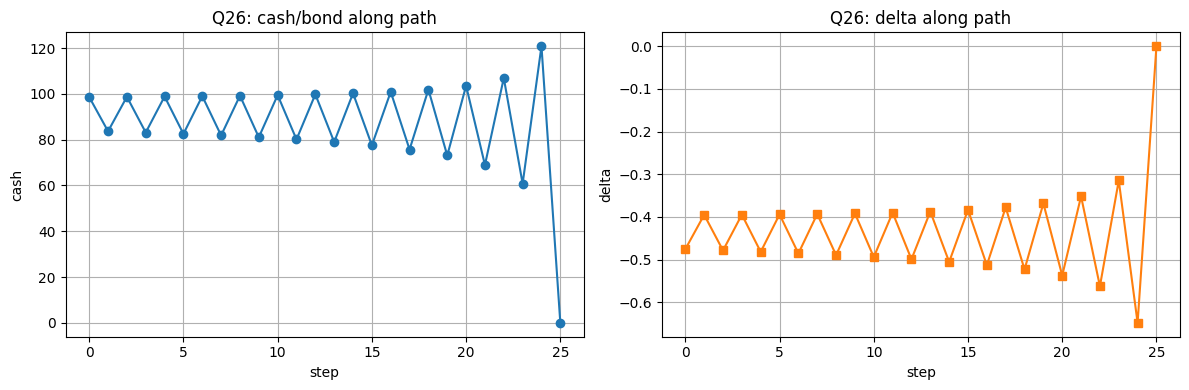

Final portfolio: 0.0  terminal payoff: 0


In [13]:
fig, ax = plt.subplots(1,2,figsize=(12,4))
ax[0].plot(am_hedge["step"], am_hedge["Cash/bond"], marker="o"); ax[0].set_title("Q26: cash/bond along path"); ax[0].set_xlabel("step"); ax[0].set_ylabel("cash"); ax[0].grid(True)
ax[1].plot(am_hedge["step"], am_hedge["Delta"], marker="s", color="C1"); ax[1].set_title("Q26: delta along path"); ax[1].set_xlabel("step"); ax[1].set_ylabel("delta"); ax[1].grid(True)
plt.tight_layout(); plt.show()
print("Final portfolio:", round(am_hedge['Portfolio'].iloc[-1],4), " terminal payoff:", round(max(Kb-am_hedge['S_t'].iloc[-1],0),4))

Versus the European put, the American needs **more active re-hedging**: delta moves more
sharply and approaches $-1$ where early exercise is optimal, forcing a larger short position. The
cash account (plotted) reflects the early-exercise value.

## Q27 — Asian ATM put: price and delta hedge (Monte-Carlo)

The Asian payoff depends on the **average** price along the path, so a recombining tree cannot
price it directly (two paths to the same node carry different running averages). We therefore use
**Monte-Carlo**, and hedge by **nested MC**: at each step along one realised path we revalue the
remaining payoff and estimate delta by a central finite-difference bump of the current spot, using
**common random numbers** so the bumped valuations share the same noise.

In [14]:
def asian_value(S_t, partial_sum, k, N, K, r, sigma, T, normals):
    """Asian put value with k monitoring points observed (partial_sum = their sum)."""
    dt = T/N; t = k*dt; rem = N-k
    if rem == 0: return max(K - partial_sum/N, 0.0)
    drift = (r-0.5*sigma**2)*dt; vol = sigma*np.sqrt(dt)
    Sfut = np.exp(np.log(S_t) + np.cumsum(drift + vol*normals[:, :rem], axis=1))
    avg = (partial_sum + Sfut.sum(axis=1)) / N
    return float(np.exp(-r*(T-t)) * np.maximum(K-avg, 0).mean())

def asian_delta(S_t, partial_sum, k, N, K, r, sigma, T, normals, h=0.01):
    Vp = asian_value(S_t*(1+h), partial_sum + S_t*h, k, N, K, r, sigma, T, normals)
    Vm = asian_value(S_t*(1-h), partial_sum - S_t*h, k, N, K, r, sigma, T, normals)
    return (Vp - Vm) / (2*h*S_t)

K_asian = S0b  # ATM
rng = np.random.default_rng(2024); dt = Tb/N25
CRN = rng.standard_normal((60000, N25))                                   # common random numbers
S_path = np.exp(np.log(S0b) + np.cumsum((rb-0.5*sigb**2)*dt + sigb*np.sqrt(dt)*rng.standard_normal(N25)))

V0 = asian_value(S0b, 0.0, 0, N25, K_asian, rb, sigb, Tb, CRN); grow = np.exp(rb*dt)
shares = asian_delta(S0b, 0.0, 0, N25, K_asian, rb, sigb, Tb, CRN); cash = V0 - shares*S0b
partial = 0.0; rows = [[0, S0b, V0, shares, shares, shares*S0b, cash, shares*S0b+cash]]
for k in range(1, N25+1):
    S_t = S_path[k-1]; partial += S_t; cash *= grow
    if k < N25:
        D_new = asian_delta(S_t, partial, k, N25, K_asian, rb, sigb, Tb, CRN)
        V_t   = asian_value(S_t, partial, k, N25, K_asian, rb, sigb, Tb, CRN)
    else:
        D_new = 0.0; V_t = max(K_asian - partial/N25, 0)
    trade = D_new - shares; cash -= trade*S_t; shares = D_new
    rows.append([k, S_t, V_t, D_new, trade, shares*S_t, cash, shares*S_t+cash])
asian_hedge = pd.DataFrame(rows, columns=["step","S_t","Asian put value","Delta","Shares traded","Stock value","Cash account","Portfolio"]).round(4)
payoff = max(K_asian - partial/N25, 0)
print(f"Asian put t0 value = {V0:.4f}")
print(f"Realised average = {partial/N25:.4f}   terminal payoff = {payoff:.4f}")
print(f"Final cash = {asian_hedge['Cash account'].iloc[-1]:.4f}   hedging residual = {asian_hedge['Cash account'].iloc[-1]-payoff:.4f}")
asian_hedge

Asian put t0 value = 7.0244
Realised average = 172.4238   terminal payoff = 7.5762
Final cash = 7.4353   hedging residual = -0.1409


,step,S_t,Asian put value,Delta,Shares traded,Stock value,Cash account,Portfolio
0,0,180.00,7.02,-0.48,-0.48,-86.42,93.44,7.02
1,1,172.48,10.73,-0.63,-0.15,-108.65,119.32,10.67
2,2,164.46,15.97,-0.77,-0.14,-126.10,141.87,15.77
3,3,163.86,16.22,-0.76,0.01,-124.24,140.52,16.29
4,4,164.40,15.66,-0.73,0.02,-120.54,136.48,15.94
5,5,157.86,20.41,-0.78,-0.05,-123.12,143.90,20.79
6,6,166.43,14.19,-0.68,0.10,-112.54,126.69,14.16
7,7,173.64,9.63,-0.56,0.12,-97.21,106.54,9.33
8,8,179.54,6.47,-0.45,0.11,-80.21,86.28,6.08
9,9,176.71,7.45,-0.48,-0.03,-84.51,91.88,7.37


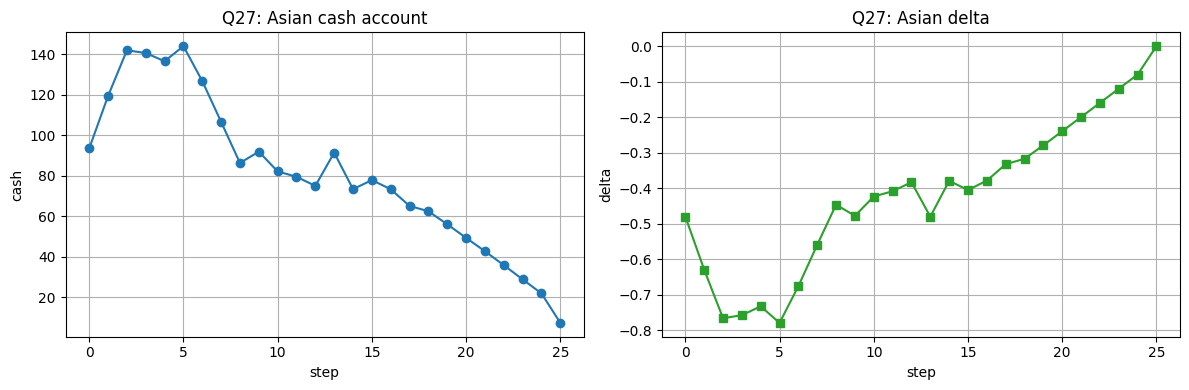

In [15]:
fig, ax = plt.subplots(1,2,figsize=(12,4))
ax[0].plot(asian_hedge["step"], asian_hedge["Cash account"], marker="o"); ax[0].set_title("Q27: Asian cash account"); ax[0].set_xlabel("step"); ax[0].set_ylabel("cash"); ax[0].grid(True)
ax[1].plot(asian_hedge["step"], asian_hedge["Delta"], marker="s", color="C2"); ax[1].set_title("Q27: Asian delta"); ax[1].set_xlabel("step"); ax[1].set_ylabel("delta"); ax[1].grid(True)
plt.tight_layout(); plt.show()

The Asian put (**≈ 7.02**) is far cheaper than the American (**13.04**) — averaging shrinks
payoff dispersion. Its delta is **smoother and shrinks toward expiry** (the seller rebalances
gently), and the MC hedge leaves a **small non-zero residual** — the discretisation + path-dependence
error, unlike the tree which reconciled exactly. This is why path-dependent options are harder to
hedge than vanillas.

## Summary of computed prices

| Question | Result |
|---|---|
| Q8 American call / put | 4.61 / 3.48 |
| Q9 American delta call / put | +0.57 / −0.45 |
| Q10 Vega (Δprice on +5% vol) | +0.99 / +0.98 |
| Q15 / Q16 trinomial European (5 strikes) | see tables |
| Q25 European put (3-step) | 13.82 |
| Q26 American put (25-step) | 13.04 (Eu 12.88) |
| Q27 Asian ATM put (MC) | 7.02 |

All European parity checks hold within rounding; American call = European call (no dividends);
American put > European put by the early-exercise premium.